ACROSS-PARTICIPANT RSA

ISPC: correlates each participant's voxel pattern for each event with the group mean pattern for that event (excluding themselves)
separately for moral and non-moral sentences
average across left and right hemisphere
paired t test


In [4]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel, pearsonr, ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns
from scipy.stats import sem
from scipy.signal import detrend


In [5]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

whichFoundationScore = "MAC_a_moral_nonmoral"

In [6]:
whichVersion = 'persentence' #persentence, 3sec, 6sec

# save
save_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/RSA/"
)

groupSplit_dir = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
    )

In [8]:
# ------------------------
# Load 
# ------------------------

whichROI = "hippocampus" # hippocampus,TPJ_refined_mask,posSTG_MTG_refined_mask,antSTG_MTG_refined_mask,tempPole_HOonly

whichStory = "shapesphysical"  # shapessocial, shapesphysical, prettymouthaffair,prettymouthparanoia,

base_dir = os.path.expanduser("D:\processed_first_level_per_sentence")

if whichVersion =='persentence':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichVersion =='3sec':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_3_seconds_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichVersion =='6sec':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_6_seconds_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

data_dir = f"{base_dir}{whichStory}/"

left = np.load(data_dir + f"{whichStory}_{whichROI}_L_3D_clean.npy")
right = np.load(data_dir + f"{whichStory}_{whichROI}_R_3D_clean.npy")

# if whichStory == 'shapesphysical':
#     left = left[:, :306, :]
#     right = right[:, :306, :]

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
C:\Users\micha\AppData\Local\Temp\ipykernel_16476\232367903.py:9: SyntaxWarning: invalid escape sequence '\p'
  base_dir = os.path.expanduser("D:\processed_first_level_per_sentence")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/shapesphysical_MFT_MAC.xlsx'

In [5]:
foundationScores['end']

0       3.175
1       5.858
2      10.544
3      13.448
4      16.992
       ...   
82    438.510
83    439.872
84    441.755
85    444.980
86    452.352
Name: end, Length: 87, dtype: float64

In [6]:
(foundationScores['end'] / 1.5) + 3

0       5.116667
1       6.905333
2      10.029333
3      11.965333
4      14.328000
         ...    
82    295.340000
83    296.248000
84    297.503333
85    299.653333
86    304.568000
Name: end, Length: 87, dtype: float64

In [7]:
left[:,:200,6]

array([[ 1.41330549,  1.04407498,  1.41378642, ...,  0.44169279,
        -0.56686003,  0.30648391],
       [ 3.6102052 ,  1.63860503,  1.27475193, ..., -0.96458113,
        -1.52405172, -0.87731244],
       [ 3.29838334,  1.22540892, -0.03681331, ...,  0.17423865,
        -1.64939179,  0.08865485],
       ...,
       [ 0.30744502, -0.81264371, -0.63581441, ..., -0.02558375,
        -2.05184379, -1.50044855],
       [ 1.3388631 , -0.9765605 ,  1.14305171, ..., -1.96115882,
        -1.82243314, -0.11300732],
       [ 0.59799799,  0.5097151 ,  1.4680291 , ..., -0.8395652 ,
        -0.05973988,  0.13725978]])

In [8]:
left.shape

(652, 309, 58)

In [9]:
meanData = np.mean(left,axis=0)
meanData.shape

(309, 58)

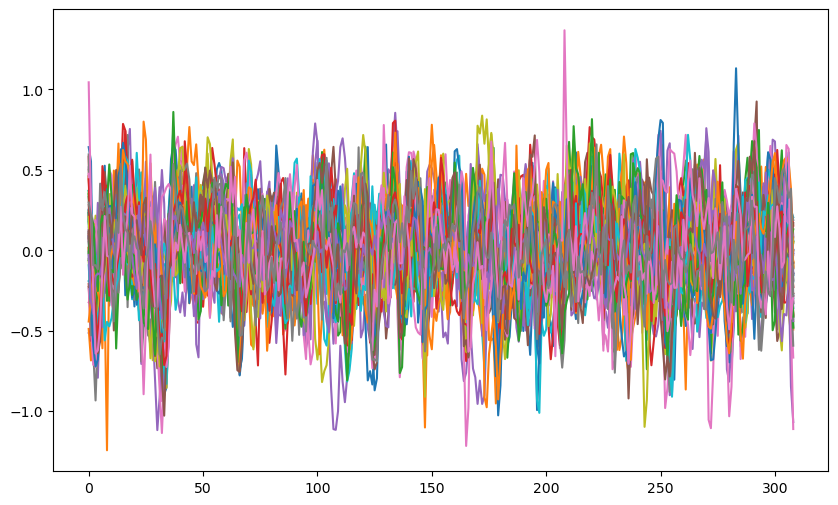

In [10]:
x = np.arange(meanData.shape[0])
plt.figure(figsize=(10, 6))
for i in range(meanData.shape[1]):   # loop over 58 columns
    plt.plot(x, meanData[:, i])

(309,)


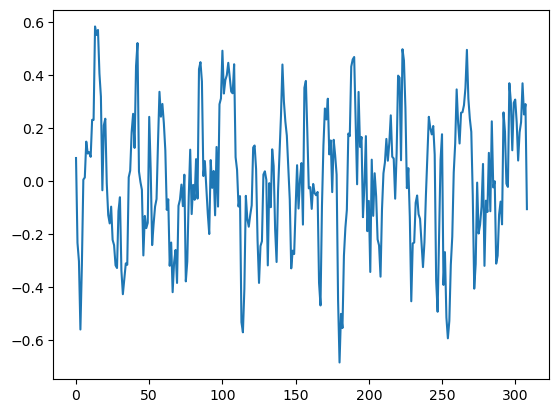

In [11]:
plt.plot(x, meanData[:, 3])
print(meanData[:, 3].shape)

In [12]:
# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec

foundationScoresSelect = foundationScores[[whichFoundationScore,"start","end"]]
foundationScoresSelect = foundationScoresSelect.copy()

# go from seconds to TRs for start and end column
foundationScoresSelect["startTR"] = foundationScoresSelect["start"] / 1.5
foundationScoresSelect["endTR"] = foundationScoresSelect["end"] / 1.5

# round to full TRs/volumes
foundationScoresSelect["startTR"] = foundationScoresSelect["startTR"].round(0).astype(int)
foundationScoresSelect["endTR"] = foundationScoresSelect["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
foundationScoresSelect['startTR'] = foundationScoresSelect['startTR'] + 3
foundationScoresSelect['endTR'] = foundationScoresSelect['endTR'] + 3


In [13]:
# split into the moral vs non moral sentences
foundationScoresSelect_nonzero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] != 0]

foundationScoresSelect_zero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] == 0]


Running ISPC for LEFT hemisphere...
Running ISPC for RIGHT hemisphere...

Participant-level ISPC results
t = 1.01, p = 0.3181


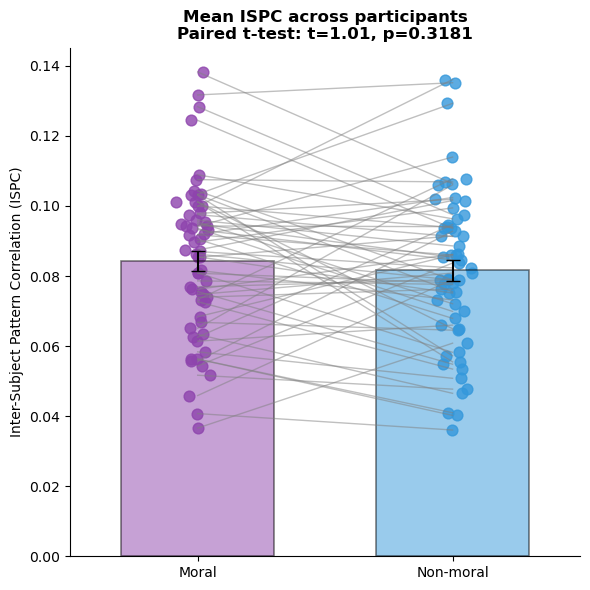

In [14]:

# ================================================================
# Function: Inter-Subject Pattern Correlation (ISPC)
# ================================================================
def run_inter_subject_pattern_correlation(data_array, events):
    """
    Compute inter-subject pattern correlation (ISPC) for each event
    and return the average ISPC per participant.
    
    data_array : np.ndarray
        Shape (voxels x TRs x participants)
    events : pd.DataFrame
        Columns ['startTR', 'endTR']
    
    Returns
    -------
    ispc_per_participant : np.ndarray
        Mean ISPC per participant across all events.
    """
    # Clean and prepare events
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR'] = events['endTR'].astype(int)
    n_events = len(events)
    n_vox, n_tr, n_part = data_array.shape

    # Z-score each participant voxelwise over time
    data_z = np.zeros_like(data_array)
    for p in range(n_part):
    #    print('participant; ',p)
        data_z[:, :, p] = zscore(data_array[:, :, p], axis=1, ddof=1)
    #    print(np.mean(data_z))

    # Compute mean spatial pattern per event per participant
    event_patterns = np.zeros((n_vox, n_events, n_part))
    for i, ev in events.iterrows():
        start_tr = int(ev['startTR'])
        end_tr = int(ev['endTR'])
        event_patterns[:, i, :] = np.mean(data_z[:, start_tr:end_tr + 1, :], axis=1)

    # Compute ISPC (inter-subject pattern correlation)
    ispc_per_participant = np.zeros(n_part)
    for p in range(n_part):
        others = np.delete(np.arange(n_part), p)
        corrs = []
        for i in range(n_events):
            this_pattern = event_patterns[:, i, p]
            others_mean = np.mean(event_patterns[:, i, others], axis=1)
            
            # nan_indices = np.argwhere(np.isnan(others_mean))
            # print('shape ', others_mean.shape)
            # print(nan_indices)
            
            r, _ = pearsonr(this_pattern, others_mean)
            corrs.append(r)
        ispc_per_participant[p] = np.mean(corrs)
    
    return ispc_per_participant


# ================================================================
# Run ISPC for both hemispheres (moral and non-moral)
# ================================================================
print("Running ISPC for LEFT hemisphere...")
ispc_moral_part_L = run_inter_subject_pattern_correlation(left, foundationScoresSelect_nonzero)
ispc_nonmoral_part_L = run_inter_subject_pattern_correlation(left, foundationScoresSelect_zero)

print("Running ISPC for RIGHT hemisphere...")
ispc_moral_part_R = run_inter_subject_pattern_correlation(right, foundationScoresSelect_nonzero)
ispc_nonmoral_part_R = run_inter_subject_pattern_correlation(right, foundationScoresSelect_zero)


# ================================================================
# Average across hemispheres (participant-level)
# ================================================================
# n_participants = min(len(ispc_moral_part_L), len(ispc_moral_part_R),
#                      len(ispc_nonmoral_part_L), len(ispc_nonmoral_part_R))

# ispc_moral_part_avg = (ispc_moral_part_L[:n_participants] + ispc_moral_part_R[:n_participants]) / 2
# ispc_nonmoral_part_avg = (ispc_nonmoral_part_L[:n_participants] + ispc_nonmoral_part_R[:n_participants]) / 2


ispc_moral_part_avg = (ispc_moral_part_L + ispc_moral_part_R) / 2
ispc_nonmoral_part_avg = (ispc_nonmoral_part_L + ispc_nonmoral_part_R) / 2


# ================================================================
# Paired t-test
# ================================================================
tval, pval = ttest_rel(ispc_moral_part_avg, ispc_nonmoral_part_avg)
print("\n===============================")
print("Participant-level ISPC results")
print("===============================")
print(f"t = {tval:.2f}, p = {pval:.4f}")


# ================================================================
# Visualization
# ================================================================
fig, ax = plt.subplots(figsize=(6, 6))
x_pos = [0, 1]
colors = ['#8E44AD', '#3498DB'] 

# Connect lines per participant
for i in range(len(ispc_moral_part_L)):
    ax.plot(x_pos,
            [ispc_moral_part_avg[i], ispc_nonmoral_part_avg[i]],
            color='gray', alpha=0.5, linewidth=1)

# Add jittered dots
ax.scatter(np.zeros(len(ispc_moral_part_L)) + np.random.normal(0, 0.03, len(ispc_moral_part_L)),
            ispc_moral_part_avg,
            color=colors[0], s=60, alpha=0.8, label='Moral')

ax.scatter(np.ones(len(ispc_moral_part_L)) + np.random.normal(0, 0.03, len(ispc_moral_part_L)),
            ispc_nonmoral_part_avg,
            color=colors[1], s=60, alpha=0.8, label='Non-moral')

# Mean + SEM bars
mean_vals = [np.mean(ispc_moral_part_avg), np.mean(ispc_nonmoral_part_avg)]
sem_vals = [np.std(ispc_moral_part_avg)/np.sqrt(len(ispc_moral_part_L)),
            np.std(ispc_nonmoral_part_avg)/np.sqrt(len(ispc_moral_part_L))]
ax.bar(x_pos, mean_vals, yerr=sem_vals, color=colors, alpha=0.5, width=0.6,
       capsize=5, edgecolor='black', linewidth=1.2)

# Aesthetics
ax.set_xticks(x_pos)
ax.set_xticklabels(['Moral', 'Non-moral'])
ax.set_ylabel('Inter-Subject Pattern Correlation (ISPC)')
ax.set_title(f'Mean ISPC across participants\nPaired t-test: t={tval:.2f}, p={pval:.4f}',
             fontsize=12, weight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(-0.5, 1.5)
plt.tight_layout()
plt.savefig(str(save_dir)+f"MoralNonmoral_{whichROI}_{whichStory}_{whichVersion}_acrossParticipants.png", dpi=300)
plt.show()


# group split for SHAPES

In [15]:


TaskOrder = pd.read_csv(groupSplit_dir+'NarrativesParticipants.csv')
TaskOrder = TaskOrder[['BIDS ID','Notes','Manipulation']]
TaskOrder = TaskOrder.dropna(how='all')
# remove duplicate rows, only 1 row per participant
TaskOrder = TaskOrder[TaskOrder['Manipulation'] == 'social']


In [16]:

def classify_order(row):
    items = [x.strip() for x in row["Notes"].split(",")]
    # Find positions, return None if not present
    try:
        pos_social = items.index("social")
        pos_physical = items.index("physical")
    except ValueError:
        return None  # one of them missing

    if pos_social < pos_physical:
        return "social_first"
    elif pos_physical < pos_social:
        return "physical_first"
    else:
        return None

TaskOrder["order"] = TaskOrder.apply(classify_order, axis=1)

social_first_ids = TaskOrder.loc[TaskOrder["order"] == "social_first", "BIDS ID"].tolist()
physical_first_ids = TaskOrder.loc[TaskOrder["order"] == "physical_first", "BIDS ID"].tolist()

print("social_first_ids", social_first_ids)
print("physical_first_ids", physical_first_ids)


social_first_ids ['sub-049', 'sub-058', 'sub-181', 'sub-186', 'sub-190', 'sub-200', 'sub-206', 'sub-207', 'sub-208', 'sub-209', 'sub-210', 'sub-211', 'sub-212', 'sub-221', 'sub-222', 'sub-223', 'sub-224', 'sub-225', 'sub-226', 'sub-227', 'sub-228', 'sub-229', 'sub-230', 'sub-231', 'sub-232', 'sub-233', 'sub-234', 'sub-235', 'sub-236', 'sub-237']
physical_first_ids ['sub-095', 'sub-115', 'sub-127', 'sub-191', 'sub-201', 'sub-213', 'sub-214', 'sub-215', 'sub-216', 'sub-217', 'sub-218', 'sub-219', 'sub-220', 'sub-238', 'sub-239', 'sub-240', 'sub-241', 'sub-242', 'sub-243', 'sub-244', 'sub-245', 'sub-246', 'sub-247', 'sub-248', 'sub-249', 'sub-250', 'sub-251', 'sub-252', 'sub-253']


In [17]:
# Remove sub-238 from the physical-first list
physical_first_ids = [x for x in physical_first_ids if x != "sub-238"]

# Convert BIDS IDs ("sub-049") → integers (49)
social_ids_int = sorted([int(x.split("-")[1]) for x in social_first_ids])
physical_ids_int = sorted([int(x.split("-")[1]) for x in physical_first_ids])

# Build full sorted ID list (should now be 58 IDs)
all_ids_sorted = sorted(social_ids_int + physical_ids_int)

# Map IDs to array indices (0–57)
id_to_index = {sub_id: idx for idx, sub_id in enumerate(all_ids_sorted)}

# Create index lists for each group
social_idx = [id_to_index[i] for i in social_ids_int]
physical_idx = [id_to_index[i] for i in physical_ids_int]

# Split arrays
moral_social = ispc_moral_part_avg[social_idx]
moral_physical = ispc_moral_part_avg[physical_idx]

nonmoral_social = ispc_nonmoral_part_avg[social_idx]
nonmoral_physical = ispc_nonmoral_part_avg[physical_idx]



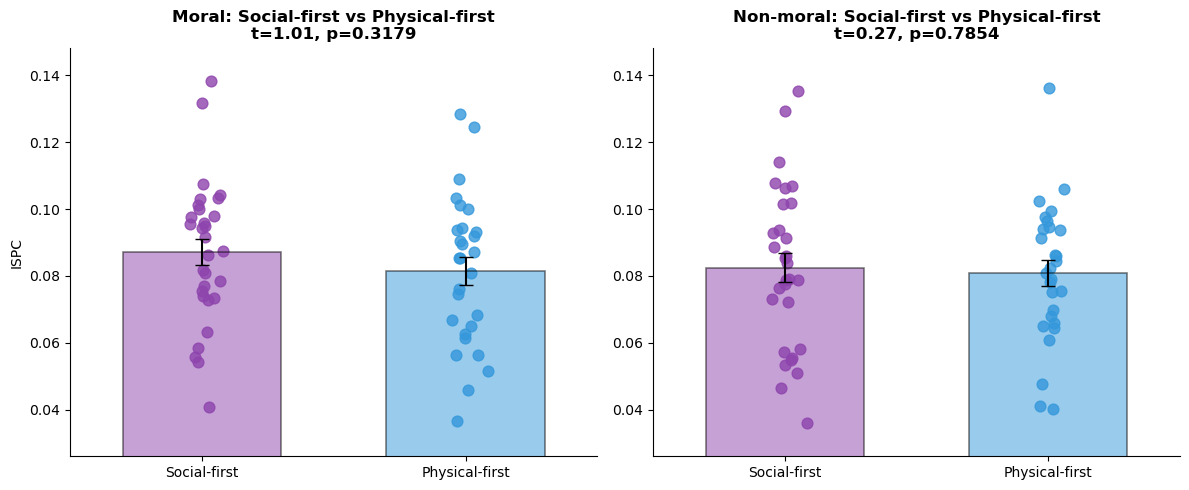

In [18]:

# ------------------------------------------------------
# Compute global y-limits across all data for consistency
# ------------------------------------------------------
all_vals = np.hstack([
    moral_social, moral_physical,
    nonmoral_social, nonmoral_physical
])
ymin = np.min(all_vals) - 0.01
ymax = np.max(all_vals) + 0.01

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#8E44AD', '#3498DB']

# ======================================================
# Panel 1 — Moral: Social-first vs Physical-first
# ======================================================
ax = axes[0]

vals1 = moral_social
vals2 = moral_physical
labels = ("Social-first", "Physical-first")

# Independent t-test
tval, pval = ttest_ind(vals1, vals2)

# Jittered points
jitter1 = np.random.normal(0, 0.03, len(vals1))
jitter2 = np.random.normal(0, 0.03, len(vals2))

ax.scatter(np.zeros(len(vals1)) + jitter1, vals1,
           color=colors[0], s=60, alpha=0.8)
ax.scatter(np.ones(len(vals2)) + jitter2, vals2,
           color=colors[1], s=60, alpha=0.8)

# Mean + SEM
mean_vals = [np.mean(vals1), np.mean(vals2)]
sem_vals = [
    np.std(vals1) / np.sqrt(len(vals1)),
    np.std(vals2) / np.sqrt(len(vals2))
]

ax.bar(
    [0, 1], mean_vals, yerr=sem_vals,
    color=colors, alpha=0.5, width=0.6,
    capsize=5, edgecolor='black', linewidth=1.2
)

ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_ylabel("ISPC")
ax.set_title(
    f"Moral: Social-first vs Physical-first\nt={tval:.2f}, p={pval:.4f}",
    fontsize=12, weight='bold'
)
ax.set_ylim(ymin, ymax)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(-0.5, 1.5)


# ======================================================
# Panel 2 — Non-moral: Social-first vs Physical-first
# ======================================================
ax = axes[1]

vals1 = nonmoral_social
vals2 = nonmoral_physical
labels = ("Social-first", "Physical-first")

# Independent t-test
tval, pval = ttest_ind(vals1, vals2)

# Jittered points
jitter1 = np.random.normal(0, 0.03, len(vals1))
jitter2 = np.random.normal(0, 0.03, len(vals2))

ax.scatter(np.zeros(len(vals1)) + jitter1, vals1,
           color=colors[0], s=60, alpha=0.8)
ax.scatter(np.ones(len(vals2)) + jitter2, vals2,
           color=colors[1], s=60, alpha=0.8)

# Mean + SEM
mean_vals = [np.mean(vals1), np.mean(vals2)]
sem_vals = [
    np.std(vals1) / np.sqrt(len(vals1)),
    np.std(vals2) / np.sqrt(len(vals2))
]

ax.bar(
    [0, 1], mean_vals, yerr=sem_vals,
    color=colors, alpha=0.5, width=0.6,
    capsize=5, edgecolor='black', linewidth=1.2
)


ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_title(
    f"Non-moral: Social-first vs Physical-first\nt={tval:.2f}, p={pval:.4f}",
    fontsize=12, weight='bold'
)
ax.set_ylim(ymin, ymax)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(-0.5, 1.5)

plt.tight_layout()
plt.savefig(str(save_dir)+f"MoralNonmoral_{whichROI}_{whichStory}_{whichVersion}_acrossParticipants_groupSplit.png", dpi=300)

plt.show()
